In [ ]:
# Definir ruta de datos
from pathlib import Path

PROJECT_ROOT = Path.cwd()

RAW_DIR = PROJECT_ROOT / "01_RAW_DATA" / "Microsoft_AI_Damage"

print("Carpeta del proyecto:", PROJECT_ROOT)
print("Carpeta de datos:", RAW_DIR)

Carpeta del proyecto: e:\Venezuela Earthquakes\Venezuela_Earthquake_Humanitarian_Map
Carpeta de datos: e:\Venezuela Earthquakes\Venezuela_Earthquake_Humanitarian_Map\01_RAW_DATA\Microsoft_AI_Damage


In [2]:
# Buscar GeoPackage
gpkg_files = list(RAW_DIR.rglob("*.gpkg"))

print(f"GeoPackages encontrados: {len(gpkg_files)}")

for file in gpkg_files:
    print(file.relative_to(PROJECT_ROOT))

GeoPackages encontrados: 4
01_RAW_DATA\Microsoft_AI_Damage\Caraballeda\caraballeda_east_vantor_6-26_building_predictions_merged.gpkg
01_RAW_DATA\Microsoft_AI_Damage\Catia_La_Mar\predicted_damage_catia_la_mar_footprints.gpkg
01_RAW_DATA\Microsoft_AI_Damage\Catia_La_Mar_East\predicted_damage_east-catia-la-mar-skysat-final.gpkg
01_RAW_DATA\Microsoft_AI_Damage\La_Guaira\predicted_damage_la-guaira-east-blacksky-06-25-model-337_filtered.gpkg


In [3]:
# Upload
import geopandas as gpd

datasets = {}

for file in gpkg_files:
    area_name = file.parent.name
    gdf = gpd.read_file(file)

    datasets[area_name] = gdf

    print("\nÁrea:", area_name)
    print("Archivo:", file.name)
    print("Registros:", len(gdf))
    print("CRS:", gdf.crs)
    print("Columnas:", gdf.columns.tolist())


Área: Caraballeda
Archivo: caraballeda_east_vantor_6-26_building_predictions_merged.gpkg
Registros: 10392
CRS: EPSG:32619
Columnas: ['id', 'damage_pct_0m', 'damage_pct_10m', 'damage_pct_20m', 'damaged', 'unknown_pct', 'geometry']

Área: Catia_La_Mar
Archivo: predicted_damage_catia_la_mar_footprints.gpkg
Registros: 30761
CRS: EPSG:32619
Columnas: ['id', 'damage_pct_0m', 'damage_pct_10m', 'damage_pct_20m', 'damaged', 'unknown_pct', 'geometry']

Área: Catia_La_Mar_East
Archivo: predicted_damage_east-catia-la-mar-skysat-final.gpkg
Registros: 24732
CRS: EPSG:32619
Columnas: ['id', 'damage_pct_0m', 'damage_pct_10m', 'damage_pct_20m', 'damaged', 'unknown_pct', 'geometry']

Área: La_Guaira
Archivo: predicted_damage_la-guaira-east-blacksky-06-25-model-337_filtered.gpkg
Registros: 5411
CRS: EPSG:32619
Columnas: ['id', 'damage_pct_0m', 'damage_pct_10m', 'damage_pct_20m', 'damaged', 'unknown_pct', 'geometry']


In [4]:
# Porcentajes y distincion de umbrales
for area_name, gdf in datasets.items():
    print("\n" + "=" * 70)
    print("Área:", area_name)

    for column in [
        "damage_pct_0m",
        "damage_pct_10m",
        "damage_pct_20m",
        "unknown_pct",
        "damaged"
    ]:
        print(f"\n{column}")
        print(gdf[column].describe())


Área: Caraballeda

damage_pct_0m
count    10392.000000
mean         0.031833
std          0.160049
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: damage_pct_0m, dtype: float64

damage_pct_10m
count    10392.000000
mean         0.027817
std          0.123013
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: damage_pct_10m, dtype: float64

damage_pct_20m
count    10392.000000
mean         0.025311
std          0.101693
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: damage_pct_20m, dtype: float64

unknown_pct
count    10392.000000
mean         0.283414
std          0.442419
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: unknown_pct, dtype: float64

damaged
count    10392.000000
mean         0.059854
std          0.23722

In [5]:
# valores unicos
for area_name, gdf in datasets.items():
    print("\nÁrea:", area_name)
    print(gdf["damaged"].value_counts(dropna=False))


Área: Caraballeda
damaged
0    9770
1     622
Name: count, dtype: int64

Área: Catia_La_Mar
damaged
0    21627
1     9134
Name: count, dtype: int64

Área: Catia_La_Mar_East
damaged
0    23523
1     1209
Name: count, dtype: int64

Área: La_Guaira
damaged
0    5299
1     112
Name: count, dtype: int64


In [6]:
# cuantos edifi superan distintos umbrales
thresholds = [0.20, 0.40, 0.60, 0.80]

for area_name, gdf in datasets.items():
    print("\n" + "=" * 70)
    print("Área:", area_name)
    print("Total de edificios:", len(gdf))

    for threshold in thresholds:
        count = (gdf["damage_pct_0m"] >= threshold).sum()
        percentage = count / len(gdf) * 100

        print(
            f"damage_pct_0m >= {threshold:.2f}: "
            f"{count:,} edificios ({percentage:.2f}%)"
        )


Área: Caraballeda
Total de edificios: 10392
damage_pct_0m >= 0.20: 412 edificios (3.96%)
damage_pct_0m >= 0.40: 351 edificios (3.38%)
damage_pct_0m >= 0.60: 296 edificios (2.85%)
damage_pct_0m >= 0.80: 244 edificios (2.35%)

Área: Catia_La_Mar
Total de edificios: 30761
damage_pct_0m >= 0.20: 6,547 edificios (21.28%)
damage_pct_0m >= 0.40: 5,474 edificios (17.80%)
damage_pct_0m >= 0.60: 4,581 edificios (14.89%)
damage_pct_0m >= 0.80: 3,800 edificios (12.35%)

Área: Catia_La_Mar_East
Total de edificios: 24732
damage_pct_0m >= 0.20: 693 edificios (2.80%)
damage_pct_0m >= 0.40: 520 edificios (2.10%)
damage_pct_0m >= 0.60: 389 edificios (1.57%)
damage_pct_0m >= 0.80: 279 edificios (1.13%)

Área: La_Guaira
Total de edificios: 5411
damage_pct_0m >= 0.20: 112 edificios (2.07%)
damage_pct_0m >= 0.40: 112 edificios (2.07%)
damage_pct_0m >= 0.60: 90 edificios (1.66%)
damage_pct_0m >= 0.80: 71 edificios (1.31%)


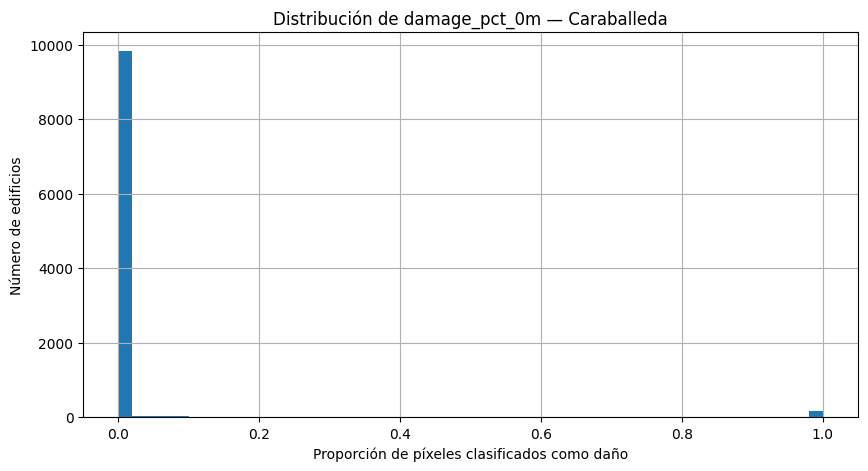

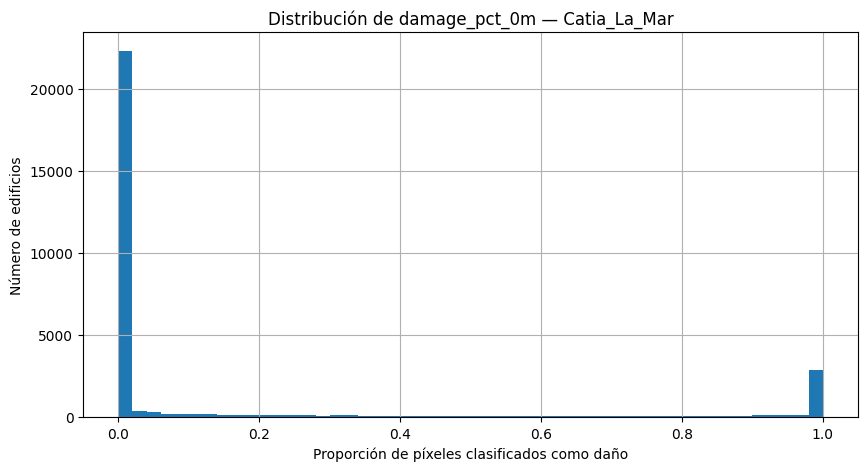

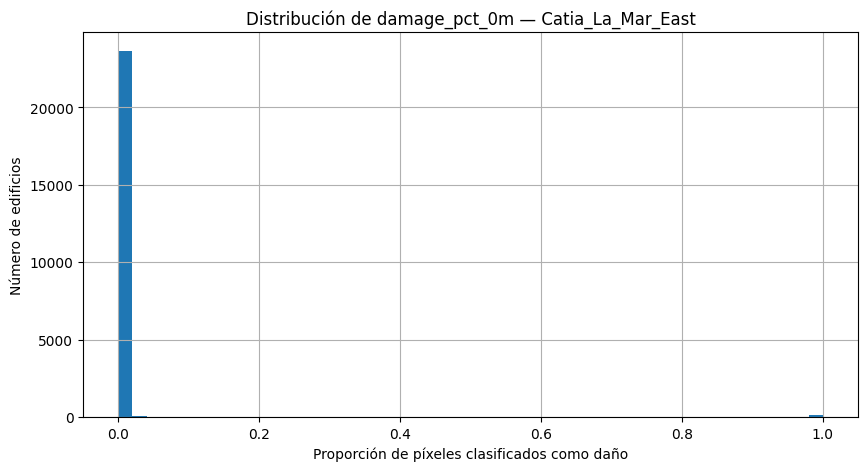

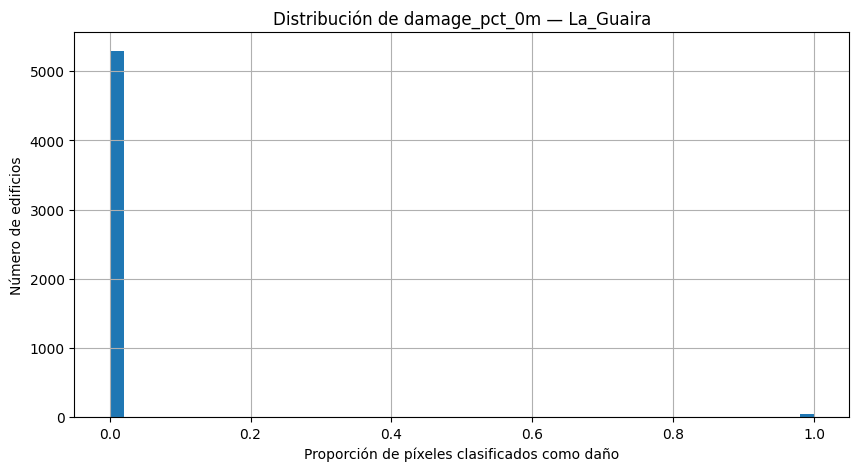

In [9]:
# Revicion de distribucion
import matplotlib.pyplot as plt

for area_name, gdf in datasets.items():
    fig, ax = plt.subplots(figsize=(10, 5))

    gdf["damage_pct_0m"].hist(
        bins=50,
        ax=ax
    )

    ax.set_title(f"Distribución de damage_pct_0m — {area_name}")
    ax.set_xlabel("Proporción de píxeles clasificados como daño")
    ax.set_ylabel("Número de edificios")

    plt.show()

In [10]:
for area_name, gdf in datasets.items():
    print("\n" + "=" * 60)
    print(area_name)

    print("\nValores más frecuentes de damage_pct_0m:")
    print(
        gdf["damage_pct_0m"]
        .round(3)
        .value_counts(dropna=False)
        .head(15)
    )

    print("\nCuantiles:")
    print(
        gdf["damage_pct_0m"].quantile(
            [0, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1]
        )
    )


Caraballeda

Valores más frecuentes de damage_pct_0m:
damage_pct_0m
0.000    9773
1.000     146
0.002      10
0.014       6
0.001       6
0.043       5
0.090       5
0.010       5
0.998       5
0.024       4
0.035       4
0.003       4
0.005       4
0.007       4
0.967       4
Name: count, dtype: int64

Cuantiles:
0.00    0.00000
0.25    0.00000
0.50    0.00000
0.75    0.00000
0.90    0.00000
0.95    0.04211
0.99    1.00000
1.00    1.00000
Name: damage_pct_0m, dtype: float64

Catia_La_Mar

Valores más frecuentes de damage_pct_0m:
damage_pct_0m
0.000    21633
1.000     2654
0.003       64
0.002       54
0.007       52
0.006       48
0.012       44
0.004       41
0.017       39
0.001       39
0.005       38
0.010       32
0.015       32
0.008       32
0.013       30
Name: count, dtype: int64

Cuantiles:
0.00    0.000000
0.25    0.000000
0.50    0.000000
0.75    0.065831
0.90    0.947368
0.95    1.000000
0.99    1.000000
1.00    1.000000
Name: damage_pct_0m, dtype: float64

Catia_La_Mar_

In [11]:
for area_name, gdf in datasets.items():
    values = gdf["damage_pct_0m"]

    categories = {
        "Sin daño detectado": values == 0,
        "Posible daño > 0 y < 0.40": (values > 0) & (values < 0.40),
        "Daño medio 0.40–0.79": (values >= 0.40) & (values < 0.80),
        "Daño alto >= 0.80": values >= 0.80,
    }

    print("\n" + "=" * 60)
    print(area_name)
    print("Total:", len(gdf))

    for label, condition in categories.items():
        count = condition.sum()
        pct = count / len(gdf) * 100
        print(f"{label}: {count:,} ({pct:.2f}%)")


Caraballeda
Total: 10392
Sin daño detectado: 9,770 (94.01%)
Posible daño > 0 y < 0.40: 271 (2.61%)
Daño medio 0.40–0.79: 107 (1.03%)
Daño alto >= 0.80: 244 (2.35%)

Catia_La_Mar
Total: 30761
Sin daño detectado: 21,627 (70.31%)
Posible daño > 0 y < 0.40: 3,660 (11.90%)
Daño medio 0.40–0.79: 1,674 (5.44%)
Daño alto >= 0.80: 3,800 (12.35%)

Catia_La_Mar_East
Total: 24732
Sin daño detectado: 23,523 (95.11%)
Posible daño > 0 y < 0.40: 689 (2.79%)
Daño medio 0.40–0.79: 241 (0.97%)
Daño alto >= 0.80: 279 (1.13%)

La_Guaira
Total: 5411
Sin daño detectado: 5,299 (97.93%)
Posible daño > 0 y < 0.40: 0 (0.00%)
Daño medio 0.40–0.79: 41 (0.76%)
Daño alto >= 0.80: 71 (1.31%)


In [13]:
# damage_pct_0m vs damage

import pandas as pd

for area_name, gdf in datasets.items():
    print("\n" + "=" * 60)
    print(area_name)

    comparison = pd.crosstab(
        gdf["damaged"],
        gdf["damage_pct_0m"] >= 0.80,
        rownames=["damaged"],
        colnames=["damage_pct_0m >= 0.80"]
    )

    display(comparison)


Caraballeda


damage_pct_0m >= 0.80,False,True
damaged,,
0,9770,0
1,378,244



Catia_La_Mar


damage_pct_0m >= 0.80,False,True
damaged,,
0,21627,0
1,5334,3800



Catia_La_Mar_East


damage_pct_0m >= 0.80,False,True
damaged,,
0,23523,0
1,930,279



La_Guaira


damage_pct_0m >= 0.80,False,True
damaged,,
0,5299,0
1,41,71


In [14]:
# Crear las capas de daño alto en memoria
damage_high = {}

for area_name, gdf in datasets.items():
    filtered = gdf.loc[
        gdf["damage_pct_0m"] >= 0.80
    ].copy()

    filtered["area_name"] = area_name
    filtered["damage_class"] = "High probability"
    filtered["damage_percent"] = (
        filtered["damage_pct_0m"] * 100
    ).round(1)

    damage_high[area_name] = filtered

    print(
        f"{area_name}: "
        f"{len(filtered):,} edificios seleccionados"
    )

Caraballeda: 244 edificios seleccionados
Catia_La_Mar: 3,800 edificios seleccionados
Catia_La_Mar_East: 279 edificios seleccionados
La_Guaira: 71 edificios seleccionados


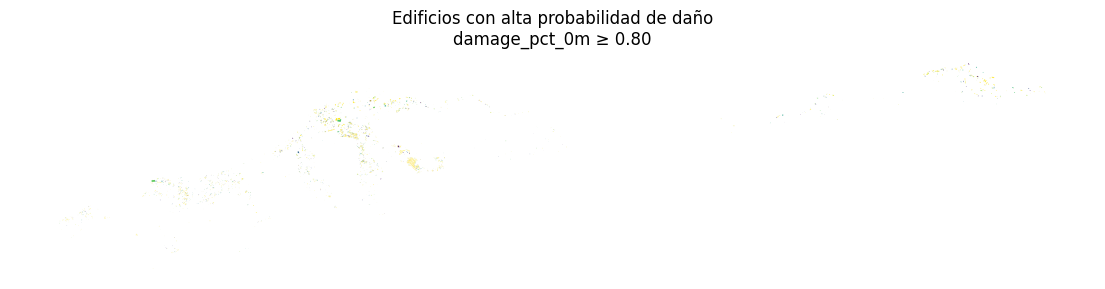

In [15]:
# Visualizar las 4 zonas juntas

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 10))

for area_name, gdf in damage_high.items():
    gdf.plot(
        ax=ax,
        column="damage_pct_0m",
        legend=False
    )

ax.set_title(
    "Edificios con alta probabilidad de daño\n"
    "damage_pct_0m ≥ 0.80"
)

ax.set_axis_off()

plt.show()

In [17]:
# mostrar edf en un solo color fig, ax = plt.subplots(figsize=(16, 10))

for area_name, gdf in damage_high.items():
    gdf.plot(
        ax=ax,
        color="red",
        edgecolor="darkred",
        linewidth=0.15,
        alpha=0.9
    )

ax.set_title(
    "Edificios con alta probabilidad de daño\n"
    "damage_pct_0m ≥ 0.80",
    fontsize=16
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

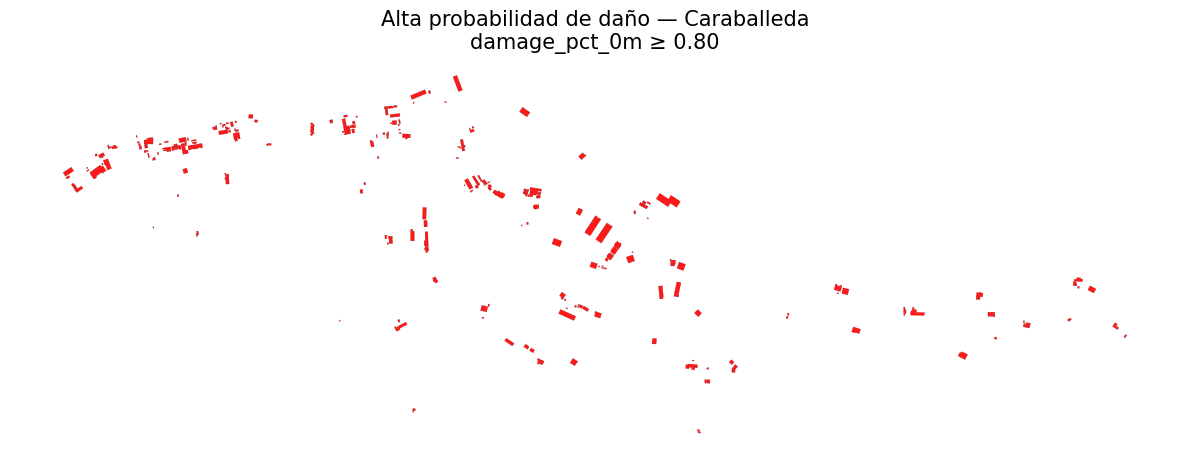

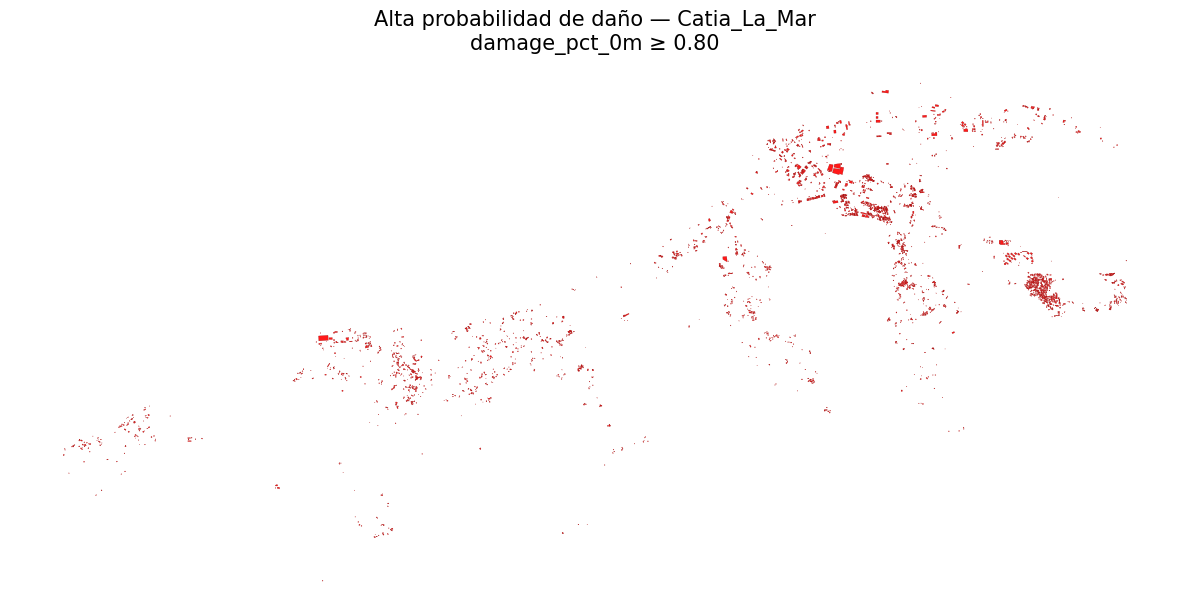

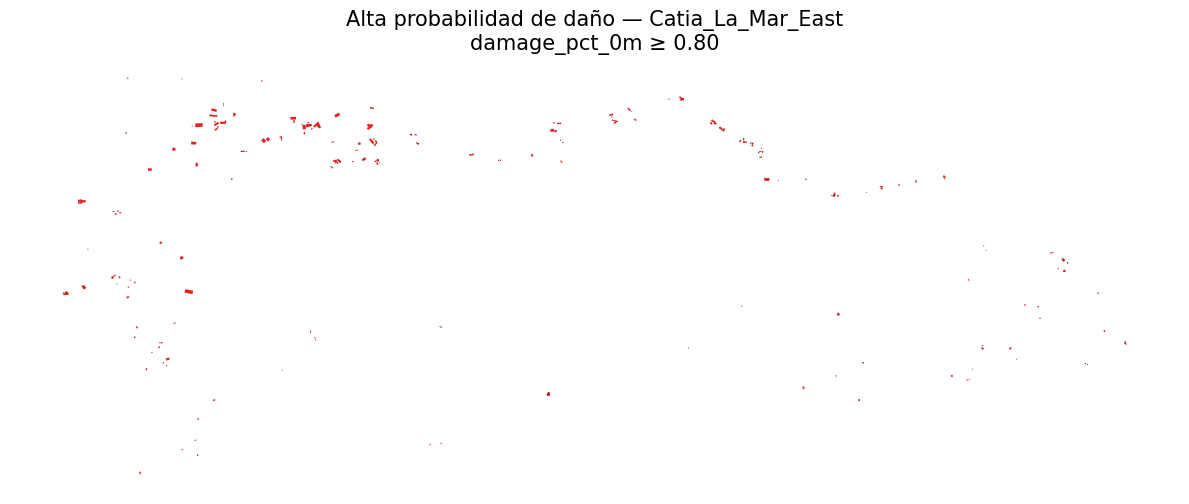

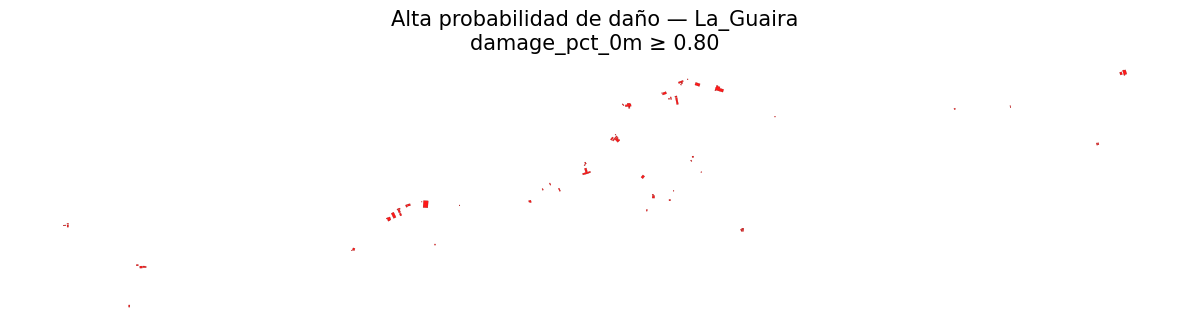

In [20]:
# visualizar cada zona por separado for area_name, gdf in damage_high.items():
for area_name, gdf in damage_high.items():
    fig, ax = plt.subplots(figsize=(12, 10))

    gdf.plot(
        ax=ax,
        color="red",
        edgecolor="darkred",
        linewidth=0.2,
        alpha=0.9
    )

    ax.set_title(
        f"Alta probabilidad de daño — {area_name}\n"
        "damage_pct_0m ≥ 0.80",
        fontsize=15
    )

    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

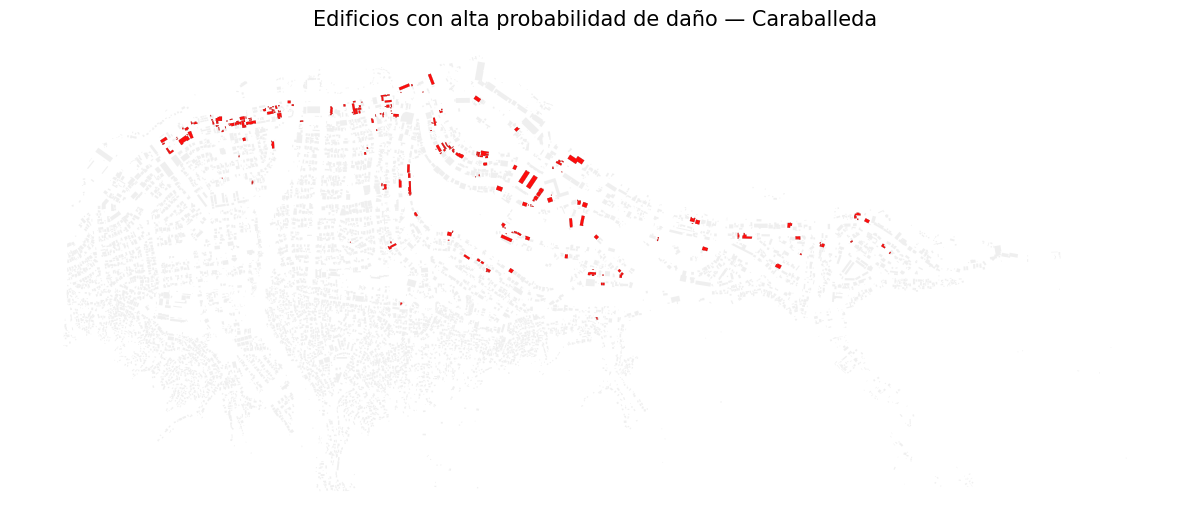

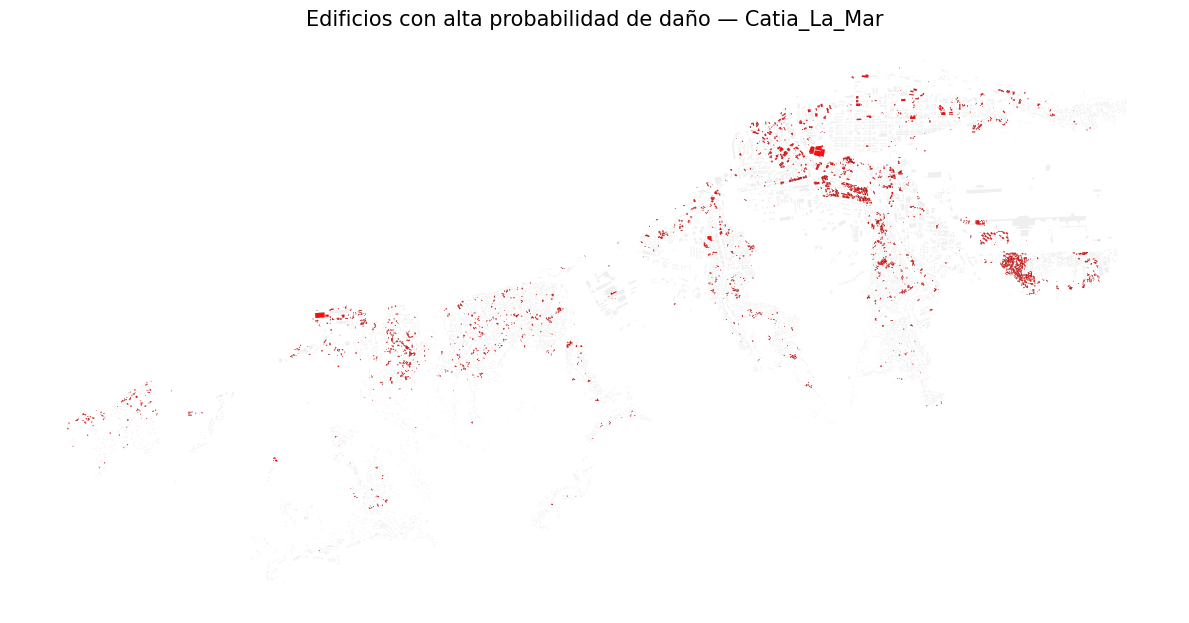

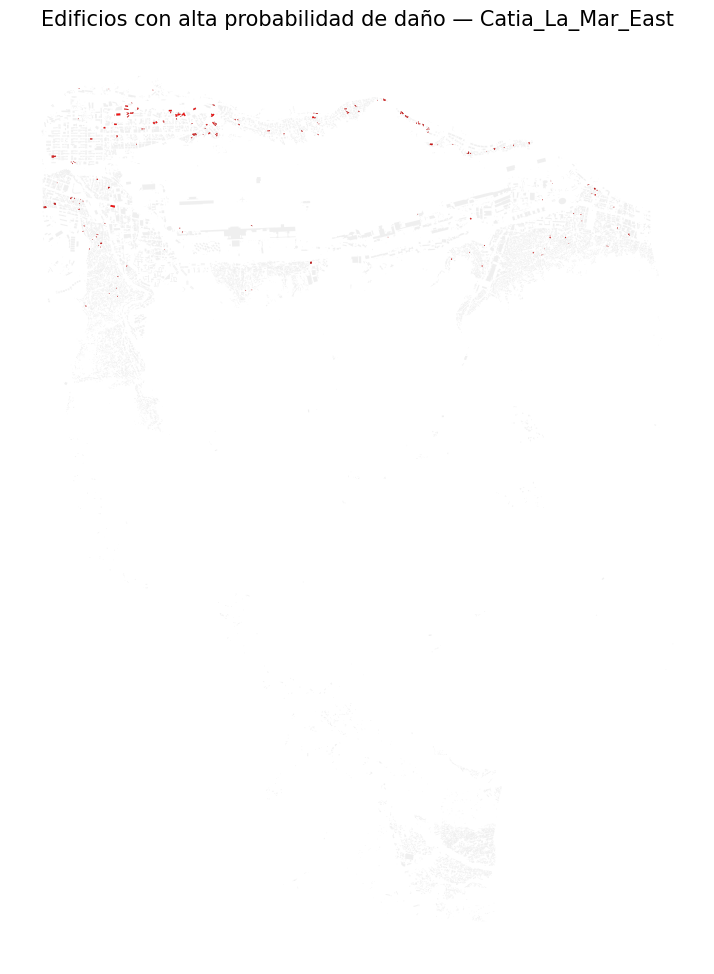

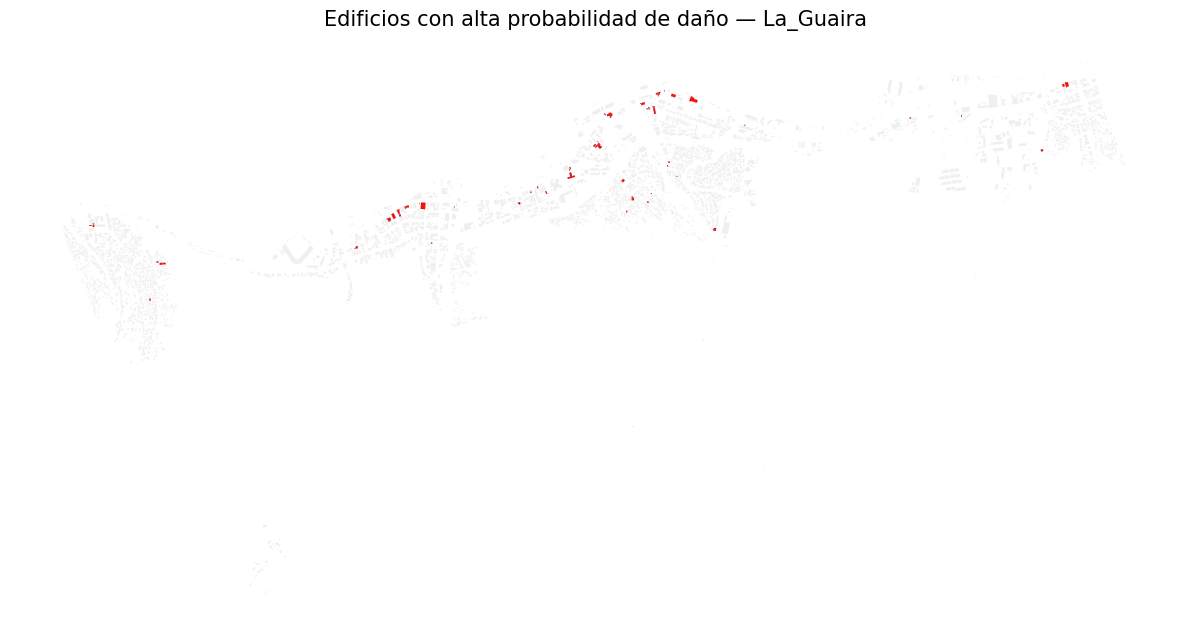

In [21]:
# anadir contexto
for area_name, all_buildings in datasets.items():
    damaged_buildings = damage_high[area_name]

    fig, ax = plt.subplots(figsize=(12, 10))

    all_buildings.plot(
        ax=ax,
        color="lightgray",
        edgecolor="none",
        alpha=0.35
    )

    damaged_buildings.plot(
        ax=ax,
        color="red",
        edgecolor="darkred",
        linewidth=0.15,
        alpha=0.95
    )

    ax.set_title(
        f"Edificios con alta probabilidad de daño — {area_name}",
        fontsize=15
    )

    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

In [23]:
# revision de solape catia = datasets["Catia_La_Mar"]

catia = datasets["Catia_La_Mar"]
catia_east = datasets["Catia_La_Mar_East"]

overlap_pairs = catia.sjoin(
    catia_east[["geometry"]],
    how="inner",
    predicate="intersects"
)

print("Intersecciones totales:", len(overlap_pairs))
print(
    "Edificios únicos de Catia La Mar:",
    overlap_pairs.index.nunique()
)
print(
    "Edificios únicos de Catia La Mar East:",
    overlap_pairs["index_right"].nunique()
)

Intersecciones totales: 20984
Edificios únicos de Catia La Mar: 13052
Edificios únicos de Catia La Mar East: 13053


In [24]:
# Revision de ID

print(
    "IDs duplicados dentro de Catia La Mar:",
    catia["id"].duplicated().sum()
)

print(
    "IDs duplicados dentro de Catia La Mar East:",
    catia_east["id"].duplicated().sum()
)

IDs duplicados dentro de Catia La Mar: 0
IDs duplicados dentro de Catia La Mar East: 0


In [25]:
# Comprobacion de ID compartidos

catia_ids = set(catia["id"].dropna())
catia_east_ids = set(catia_east["id"].dropna())

shared_ids = catia_ids.intersection(catia_east_ids)

print("IDs únicos en Catia La Mar:", len(catia_ids))
print("IDs únicos en Catia La Mar East:", len(catia_east_ids))
print("IDs compartidos entre ambas capas:", len(shared_ids))

IDs únicos en Catia La Mar: 30761
IDs únicos en Catia La Mar East: 24732
IDs compartidos entre ambas capas: 24732


In [26]:
# rango de ID
for area_name, layer in {
    "Catia_La_Mar": catia,
    "Catia_La_Mar_East": catia_east
}.items():

    print("\n", area_name)
    print("ID mínimo:", layer["id"].min())
    print("ID máximo:", layer["id"].max())
    print("Primeros 10 ID:", layer["id"].head(10).tolist())
    print("Últimos 10 ID:", layer["id"].tail(10).tolist())


 Catia_La_Mar
ID mínimo: 0
ID máximo: 30760
Primeros 10 ID: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Últimos 10 ID: [30751, 30752, 30753, 30754, 30755, 30756, 30757, 30758, 30759, 30760]

 Catia_La_Mar_East
ID mínimo: 0
ID máximo: 24731
Primeros 10 ID: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Últimos 10 ID: [24722, 24723, 24724, 24725, 24726, 24727, 24728, 24729, 24730, 24731]


In [27]:
# Crear pares
possible_duplicates = gpd.sjoin(
    catia.reset_index(names="catia_index"),
    catia_east[["geometry"]].reset_index(names="east_index"),
    how="inner",
    predicate="intersects"
)

print("Pares candidatos por intersección:", len(possible_duplicates))

Pares candidatos por intersección: 20984


In [ ]:
# Anadir Geometria Catia la Mar
east_geometries = (
    catia_east[["geometry"]]
    .reset_index(names="east_index")
    .rename(columns={"geometry": "geometry_east"})
)

possible_duplicates = possible_duplicates.merge(
    east_geometries,
    on="east_index",
    how="left"
)

print(possible_duplicates.columns.tolist())

['catia_index', 'id', 'damage_pct_0m', 'damage_pct_10m', 'damage_pct_20m', 'damaged', 'unknown_pct', 'geometry', 'index_right', 'east_index', 'geometry_east']


In [29]:
# CAlcular proporcion del solape
possible_duplicates["intersection_area"] = [
    geom_catia.intersection(geom_east).area
    for geom_catia, geom_east in zip(
        possible_duplicates["geometry"],
        possible_duplicates["geometry_east"]
    )
]

possible_duplicates["catia_area"] = (
    possible_duplicates["geometry"].area
)

possible_duplicates["east_area"] = [
    geom.area
    for geom in possible_duplicates["geometry_east"]
]

possible_duplicates["smaller_area"] = possible_duplicates[
    ["catia_area", "east_area"]
].min(axis=1)

possible_duplicates["overlap_ratio"] = (
    possible_duplicates["intersection_area"]
    / possible_duplicates["smaller_area"]
)

print("Cálculo terminado")

Cálculo terminado


In [30]:
# Revisar resultados estadisticos 
display(
    possible_duplicates["overlap_ratio"].describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.80,
            0.90,
            0.95,
            0.99
        ]
    )
)

count    2.098400e+04
mean     4.851979e-01
std      3.177394e-01
min      6.254460e-09
25%      1.199274e-01
50%      6.167469e-01
75%      7.633589e-01
80%      7.844249e-01
90%      8.293068e-01
95%      8.572042e-01
99%      9.155913e-01
max      9.755183e-01
Name: overlap_ratio, dtype: float64

In [31]:
# Contar pares segun umbrales
for threshold in [0.50, 0.70, 0.80, 0.90, 0.95]:
    selected = possible_duplicates.loc[
        possible_duplicates["overlap_ratio"] >= threshold
    ]

    print(
        f"Solape ≥ {threshold:.0%}: "
        f"{len(selected):,} pares | "
        f"{selected['catia_index'].nunique():,} edificios Catia | "
        f"{selected['east_index'].nunique():,} edificios East"
    )

Solape ≥ 50%: 12,449 pares | 12,415 edificios Catia | 12,407 edificios East
Solape ≥ 70%: 8,084 pares | 8,083 edificios Catia | 8,084 edificios East
Solape ≥ 80%: 3,442 pares | 3,442 edificios Catia | 3,442 edificios East
Solape ≥ 90%: 314 pares | 314 edificios Catia | 314 edificios East
Solape ≥ 95%: 36 pares | 36 edificios Catia | 36 edificios East


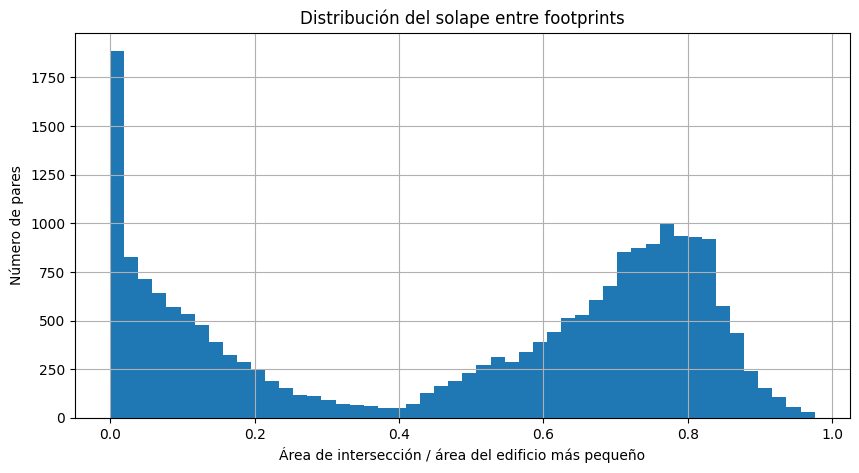

In [32]:
# Graficar distribucion

fig, ax = plt.subplots(figsize=(10, 5))

possible_duplicates["overlap_ratio"].hist(
    bins=50,
    ax=ax
)

ax.set_title("Distribución del solape entre footprints")
ax.set_xlabel(
    "Área de intersección / área del edificio más pequeño"
)
ax.set_ylabel("Número de pares")

plt.show()

In [33]:
# Buscar mascara Catia la Mar East
from pathlib import Path

east_folder = (
    PROJECT_ROOT
    / "01_RAW_DATA"
    / "Microsoft_AI_Damage"
    / "Catia_La_Mar_East"
)

east_mask_files = list(east_folder.rglob("*valid_area*.geojson"))

print("Máscaras encontradas:", len(east_mask_files))

for file in east_mask_files:
    print(file)

Máscaras encontradas: 1
e:\Venezuela Earthquakes\Venezuela_Earthquake_Humanitarian_Map\01_RAW_DATA\Microsoft_AI_Damage\Catia_La_Mar_East\valid_area_mask_catia_la_mar_east.geojson


In [34]:
# Cargas mascara
east_mask = gpd.read_file(east_mask_files[0])

print("Registros:", len(east_mask))
print("CRS original:", east_mask.crs)
print("Tipo de geometría:")
print(east_mask.geom_type.value_counts())

Registros: 1
CRS original: EPSG:4326
Tipo de geometría:
Polygon    1
Name: count, dtype: int64


In [35]:
# Reproyectar mascara
east_mask = east_mask.to_crs(catia.crs)

print("CRS edificios:", catia.crs)
print("CRS máscara:", east_mask.crs)

CRS edificios: EPSG:32619
CRS máscara: EPSG:32619


In [36]:
# Unificar geometria Catia la mar y catia la mar east
east_coverage = east_mask.geometry.union_all()

print("Tipo de cobertura:", east_coverage.geom_type)
print(
    "Área de cobertura:",
    round(east_coverage.area / 1_000_000, 2),
    "km²"
)

Tipo de cobertura: Polygon
Área de cobertura: 106.44 km²


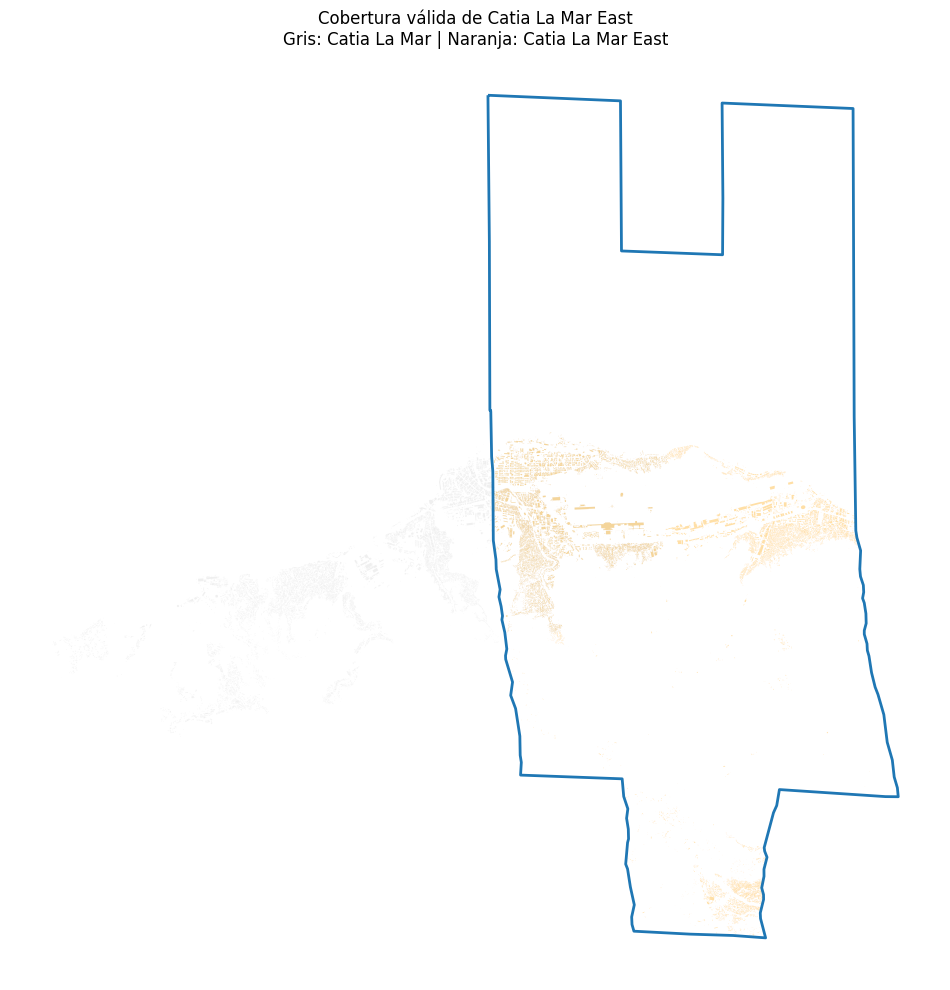

In [37]:
# Visualizar ascara sobre ambas capas 
fig, ax = plt.subplots(figsize=(14, 10))

catia.plot(
    ax=ax,
    color="lightgray",
    edgecolor="none",
    alpha=0.35
)

catia_east.plot(
    ax=ax,
    color="orange",
    edgecolor="none",
    alpha=0.35
)

east_mask.boundary.plot(
    ax=ax,
    linewidth=2
)

ax.set_title(
    "Cobertura válida de Catia La Mar East\n"
    "Gris: Catia La Mar | Naranja: Catia La Mar East"
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [38]:
# calsificar edf
catia_centroids = catia.geometry.centroid

catia_inside_east = catia_centroids.within(east_coverage)

print(
    "Edificios de Catia La Mar dentro de la cobertura East:",
    f"{catia_inside_east.sum():,}"
)

print(
    "Edificios de Catia La Mar fuera de la cobertura East:",
    f"{(~catia_inside_east).sum():,}"
)

Edificios de Catia La Mar dentro de la cobertura East: 13,038
Edificios de Catia La Mar fuera de la cobertura East: 17,723


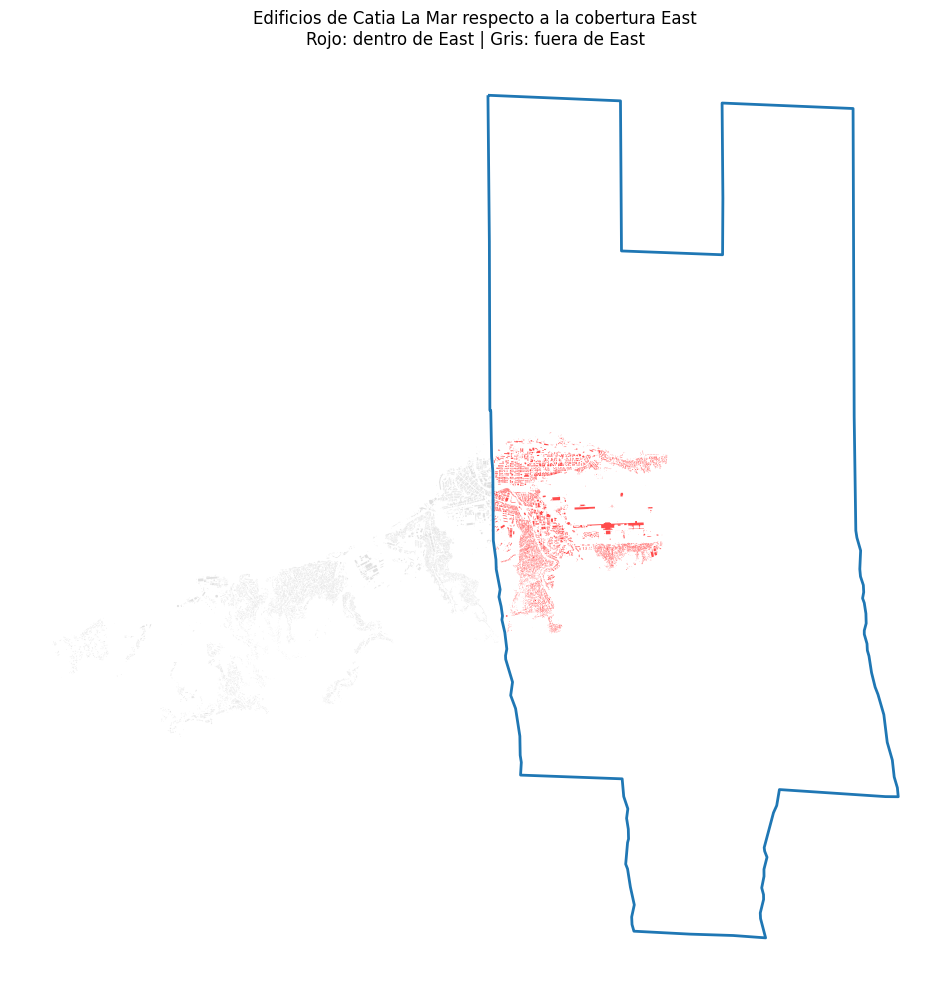

In [39]:
# verificar que se elimina
catia_inside_layer = catia.loc[catia_inside_east]
catia_outside_layer = catia.loc[~catia_inside_east]

fig, ax = plt.subplots(figsize=(14, 10))

catia_outside_layer.plot(
    ax=ax,
    color="lightgray",
    edgecolor="none",
    alpha=0.7
)

catia_inside_layer.plot(
    ax=ax,
    color="red",
    edgecolor="none",
    alpha=0.7
)

east_mask.boundary.plot(
    ax=ax,
    linewidth=2
)

ax.set_title(
    "Edificios de Catia La Mar respecto a la cobertura East\n"
    "Rojo: dentro de East | Gris: fuera de East"
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [40]:
# contar edf dentro y fuera de la mascara
print(
    "Dentro de la cobertura East:",
    f"{catia_inside_east.sum():,}"
)

print(
    "Fuera de la cobertura East:",
    f"{(~catia_inside_east).sum():,}"
)

print(
    "Total:",
    f"{len(catia):,}"
)

Dentro de la cobertura East: 13,038
Fuera de la cobertura East: 17,723
Total: 30,761


In [41]:
# conservar CLM fuera de east
catia_outside_east = catia.loc[
    ~catia_inside_east
].copy()

print(
    "Catia La Mar conservada:",
    f"{len(catia_outside_east):,}"
)

print(
    "Catia La Mar East conservada:",
    f"{len(catia_east):,}"
)

Catia La Mar conservada: 17,723
Catia La Mar East conservada: 24,732


In [42]:
# Anadir procedencia e identificadores unicos
catia_outside_east["source_area"] = "Catia_La_Mar"
catia_outside_east["assessment_date"] = "2026-06-25"
catia_outside_east["source_id"] = (
    "CLM_" + catia_outside_east["id"].astype(str)
)

catia_east_clean = catia_east.copy()

catia_east_clean["source_area"] = "Catia_La_Mar_East"
catia_east_clean["assessment_date"] = "2026-06-26"
catia_east_clean["source_id"] = (
    "CLME_" + catia_east_clean["id"].astype(str)
)

In [43]:
# Combinar las dos capas
catia_combined = gpd.GeoDataFrame(
    pd.concat(
        [
            catia_outside_east,
            catia_east_clean
        ],
        ignore_index=True
    ),
    geometry="geometry",
    crs=catia.crs
)

print(
    "Total combinado de Catia:",
    f"{len(catia_combined):,}"
)

print(
    "source_id duplicados:",
    catia_combined["source_id"].duplicated().sum()
)

Total combinado de Catia: 42,455
source_id duplicados: 0


In [44]:
# Filtrar edf con alto dano

catia_damage_high = catia_combined.loc[
    catia_combined["damage_pct_0m"] >= 0.80
].copy()

catia_damage_high["damage_percent"] = (
    catia_damage_high["damage_pct_0m"] * 100
).round(1)

catia_damage_high["damage_class"] = (
    "Alta probabilidad de daño"
)

print(
    "Edificios con alta probabilidad de daño:",
    f"{len(catia_damage_high):,}"
)

Edificios con alta probabilidad de daño: 2,113


In [45]:
# por fuente
print(
    catia_damage_high["source_area"]
    .value_counts()
)

source_area
Catia_La_Mar         1834
Catia_La_Mar_East     279
Name: count, dtype: int64


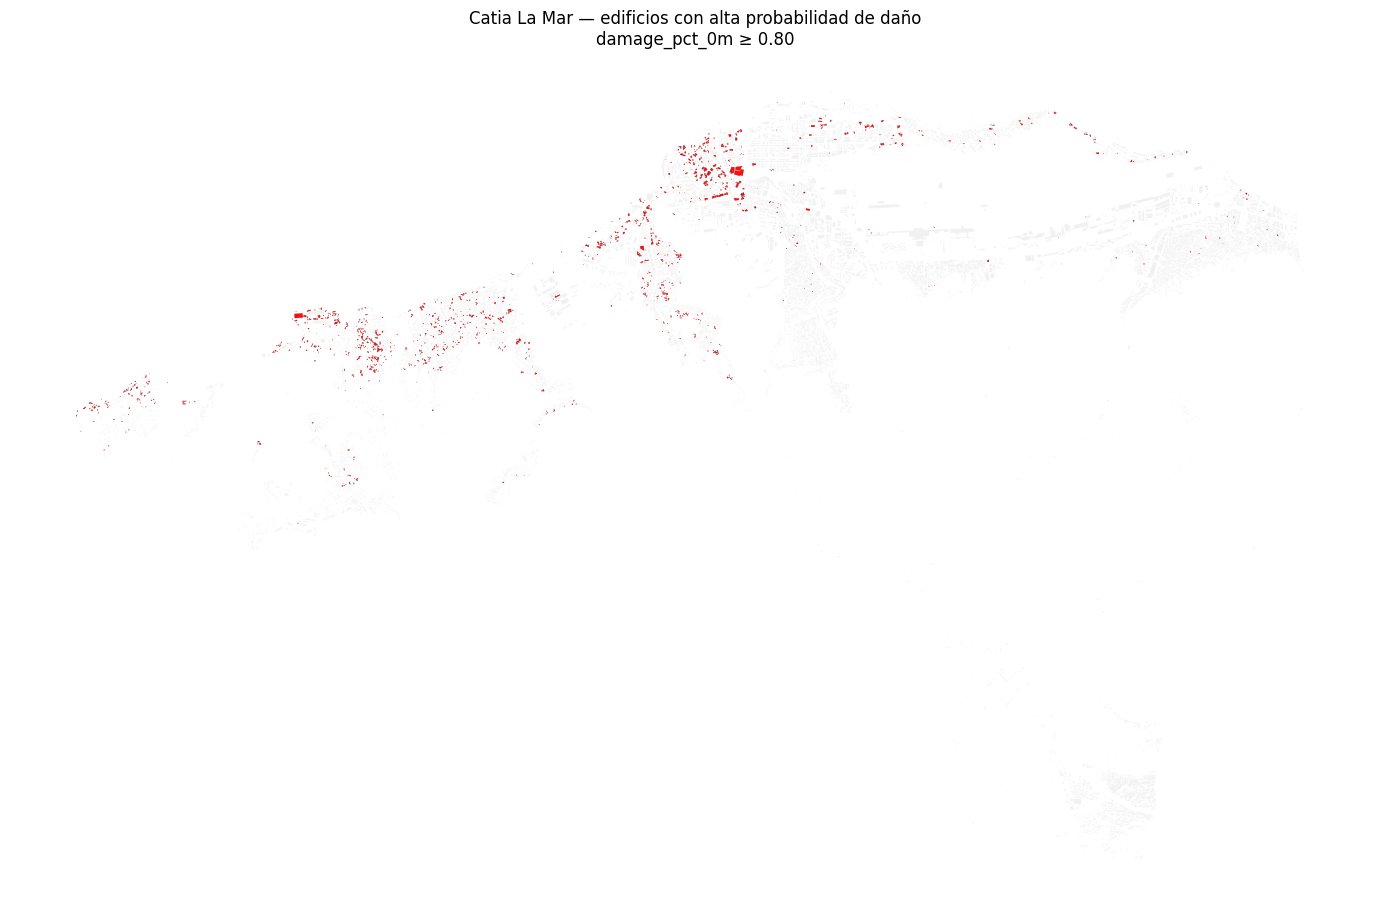

In [46]:
# Clean result viz
fig, ax = plt.subplots(figsize=(14, 10))

catia_combined.plot(
    ax=ax,
    color="lightgray",
    edgecolor="none",
    alpha=0.30
)

catia_damage_high.plot(
    ax=ax,
    color="red",
    edgecolor="darkred",
    linewidth=0.15,
    alpha=0.95
)

ax.set_title(
    "Catia La Mar — edificios con alta probabilidad de daño\n"
    "damage_pct_0m ≥ 0.80"
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [47]:
# CARABAlleda la guaira
caraballeda = datasets["Caraballeda"].copy()
la_guaira = datasets["La_Guaira"].copy()

caraballeda["source_area"] = "Caraballeda"
caraballeda["assessment_date"] = "2026-06-26"
caraballeda["source_id"] = (
    "CAR_" + caraballeda["id"].astype(str)
)

la_guaira["source_area"] = "La_Guaira"
la_guaira["assessment_date"] = "2026-06-26"
la_guaira["source_id"] = (
    "LG_" + la_guaira["id"].astype(str)
)

print("Caraballeda:", f"{len(caraballeda):,}")
print("La Guaira:", f"{len(la_guaira):,}")

Caraballeda: 10,392
La Guaira: 5,411


In [49]:
caraballeda = datasets["Caraballeda"].copy()
la_guaira = datasets["La_Guaira"].copy()

caraballeda["source_area"] = "Caraballeda"
caraballeda["assessment_date"] = "2026-06-26"
caraballeda["source_id"] = (
    "CAR_" + caraballeda["id"].astype(str)
)

la_guaira["source_area"] = "La_Guaira"
la_guaira["assessment_date"] = "2026-06-26"
la_guaira["source_id"] = (
    "LG_" + la_guaira["id"].astype(str)
)

print("Caraballeda:", len(caraballeda))
print("La Guaira:", len(la_guaira))

Caraballeda: 10392
La Guaira: 5411


In [50]:
damage_all = gpd.GeoDataFrame(
    pd.concat(
        [
            catia_combined,
            caraballeda,
            la_guaira
        ],
        ignore_index=True
    ),
    geometry="geometry",
    crs=catia_combined.crs
)

print("Total de edificios evaluados:", f"{len(damage_all):,}")
print(
    "source_id duplicados:",
    damage_all["source_id"].duplicated().sum()
)
print("CRS:", damage_all.crs)

Total de edificios evaluados: 58,258
source_id duplicados: 0
CRS: EPSG:32619


In [51]:
import numpy as np

conditions = [
    damage_all["damage_pct_0m"] >= 0.80,
    (
        (damage_all["damage_pct_0m"] >= 0.40)
        & (damage_all["damage_pct_0m"] < 0.80)
    ),
    (
        (damage_all["damage_pct_0m"] > 0)
        & (damage_all["damage_pct_0m"] < 0.40)
    ),
    damage_all["damage_pct_0m"] == 0
]

labels = [
    "Alta probabilidad",
    "Probabilidad media",
    "Posible daño",
    "Sin daño detectado"
]

damage_all["damage_class"] = np.select(
    conditions,
    labels,
    default="Sin clasificación"
)

damage_all["damage_percent"] = (
    damage_all["damage_pct_0m"] * 100
).round(1)

print("Clasificación creada correctamente")

Clasificación creada correctamente


In [52]:
damage_all["damage_class"].value_counts()

damage_class
Sin daño detectado    51259
Posible daño           3208
Alta probabilidad      2428
Probabilidad media     1363
Name: count, dtype: int64

In [53]:
# crear capa de alta probabilidad
damage_high_all = damage_all.loc[
    damage_all["damage_class"] == "Alta probabilidad"
].copy()

print(
    "Edificios con alta probabilidad de daño:",
    f"{len(damage_high_all):,}"
)

print(
    damage_high_all["source_area"]
    .value_counts()
)

Edificios con alta probabilidad de daño: 2,428
source_area
Catia_La_Mar         1834
Catia_La_Mar_East     279
Caraballeda           244
La_Guaira              71
Name: count, dtype: int64


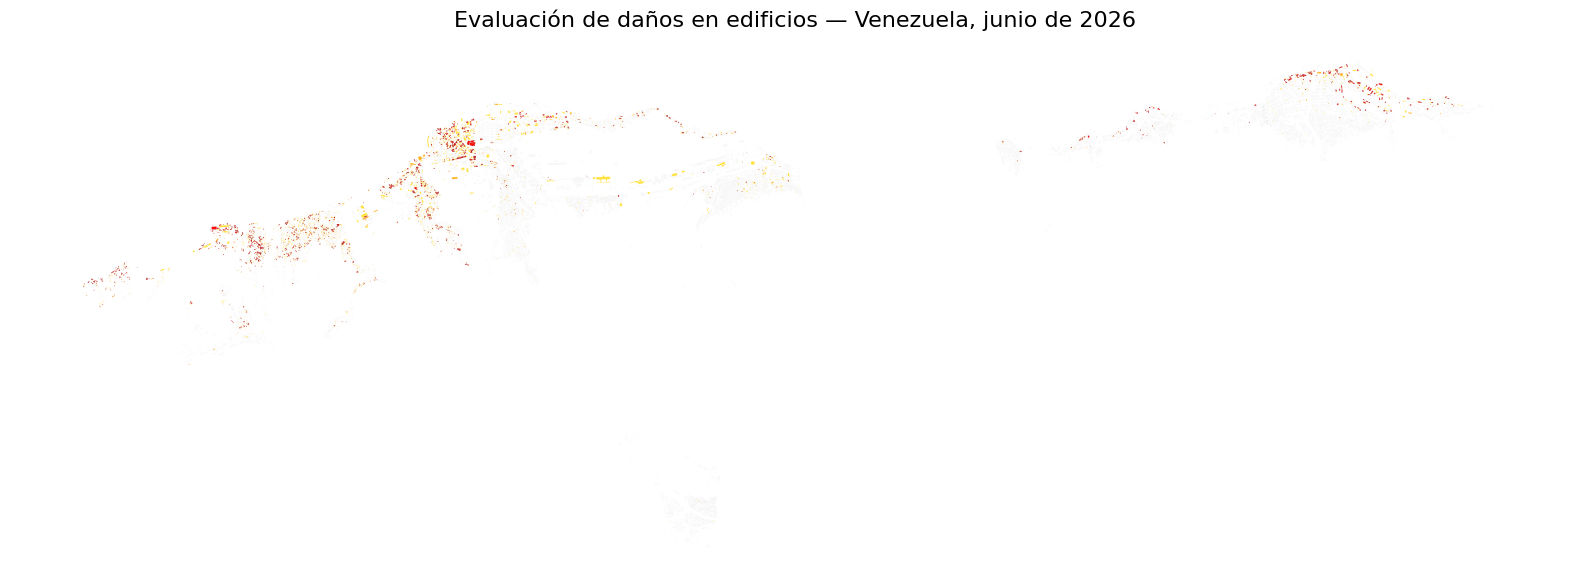

In [54]:
# categorias viz
fig, ax = plt.subplots(figsize=(16, 10))

damage_all.loc[
    damage_all["damage_class"] == "Sin daño detectado"
].plot(
    ax=ax,
    color="lightgray",
    edgecolor="none",
    alpha=0.18
)

damage_all.loc[
    damage_all["damage_class"] == "Posible daño"
].plot(
    ax=ax,
    color="gold",
    edgecolor="none",
    alpha=0.75
)

damage_all.loc[
    damage_all["damage_class"] == "Probabilidad media"
].plot(
    ax=ax,
    color="orange",
    edgecolor="none",
    alpha=0.85
)

damage_high_all.plot(
    ax=ax,
    color="red",
    edgecolor="darkred",
    linewidth=0.12,
    alpha=0.95
)

ax.set_title(
    "Evaluación de daños en edificios — Venezuela, junio de 2026",
    fontsize=16
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [55]:
# files prep for arcgis
damage_export = damage_all[
    [
        "source_id",
        "source_area",
        "assessment_date",
        "damage_pct_0m",
        "damage_pct_10m",
        "damage_pct_20m",
        "unknown_pct",
        "damage_percent",
        "damage_class",
        "geometry"
    ]
].copy()

In [56]:
# Reproyectar a WGS84
damage_export_wgs84 = damage_export.to_crs(
    epsg=4326
)

print(
    "CRS de exportación:",
    damage_export_wgs84.crs
)

CRS de exportación: EPSG:4326


In [57]:
# Exportar el GeoJSON

OUTPUT_DIR = PROJECT_ROOT / "03_ARCGIS_UPLOAD"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

output_geojson = (
    OUTPUT_DIR
    / "VEN_EQ2026_building_damage_all_categories.geojson"
)

damage_export_wgs84.to_file(
    output_geojson,
    driver="GeoJSON"
)

print("Archivo exportado:")
print(output_geojson)

Archivo exportado:
e:\Venezuela Earthquakes\Venezuela_Earthquake_Humanitarian_Map\03_ARCGIS_UPLOAD\VEN_EQ2026_building_damage_all_categories.geojson


In [58]:
# verificacion
print("Existe:", output_geojson.exists())
print(
    "Tamaño:",
    round(output_geojson.stat().st_size / 1_000_000, 2),
    "MB"
)

Existe: True
Tamaño: 31.84 MB


In [59]:
# comprobacion 
damage_check = gpd.read_file(output_geojson)

print("Registros:", len(damage_check))
print("CRS:", damage_check.crs)
print("Columnas:", damage_check.columns.tolist())
print(
    damage_check["damage_class"].value_counts()
)

Registros: 58258
CRS: EPSG:4326
Columnas: ['source_id', 'source_area', 'assessment_date', 'damage_pct_0m', 'damage_pct_10m', 'damage_pct_20m', 'unknown_pct', 'damage_percent', 'damage_class', 'geometry']
damage_class
Sin daño detectado    51259
Posible daño           3208
Alta probabilidad      2428
Probabilidad media     1363
Name: count, dtype: int64


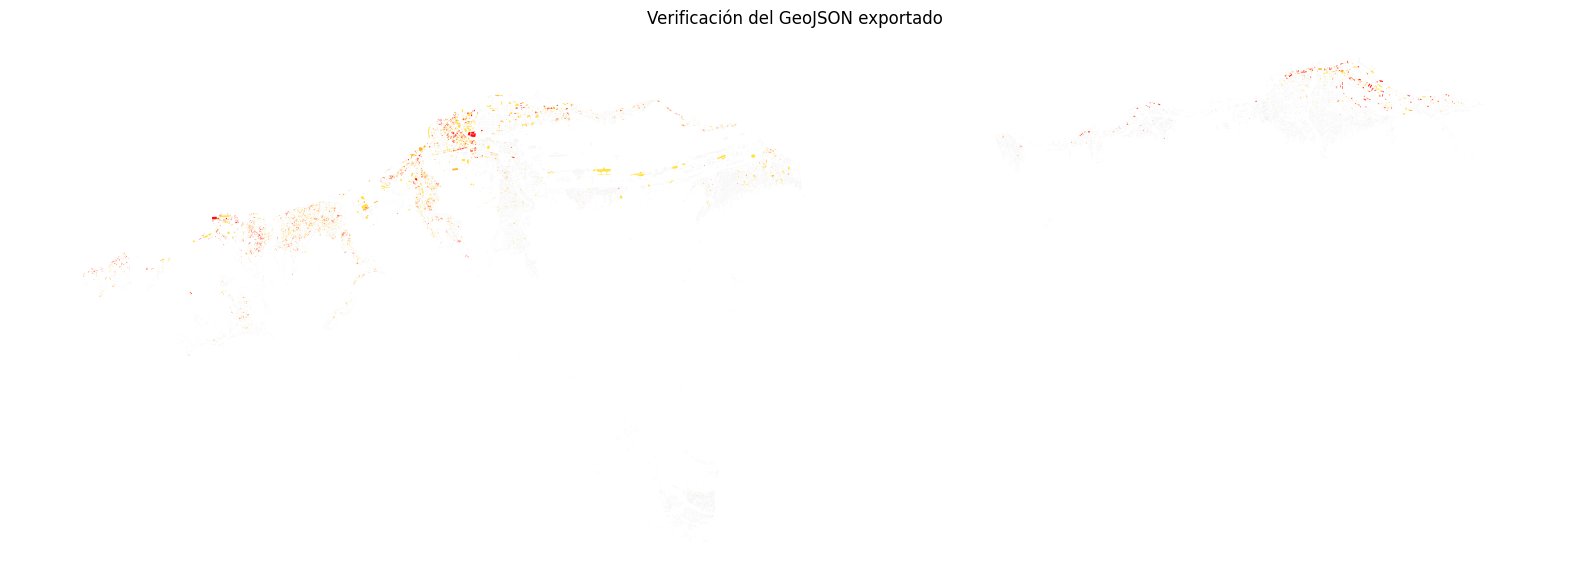

In [60]:
# visual review
fig, ax = plt.subplots(figsize=(16, 10))

damage_check.loc[
    damage_check["damage_class"] == "Sin daño detectado"
].plot(
    ax=ax,
    color="lightgray",
    edgecolor="none",
    alpha=0.15
)

damage_check.loc[
    damage_check["damage_class"] == "Posible daño"
].plot(
    ax=ax,
    color="gold",
    edgecolor="none",
    alpha=0.75
)

damage_check.loc[
    damage_check["damage_class"] == "Probabilidad media"
].plot(
    ax=ax,
    color="orange",
    edgecolor="none",
    alpha=0.85
)

damage_check.loc[
    damage_check["damage_class"] == "Alta probabilidad"
].plot(
    ax=ax,
    color="red",
    edgecolor="none",
    alpha=0.95
)

ax.set_title(
    "Verificación del GeoJSON exportado"
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [61]:
damage_detected = damage_export_wgs84.loc[
    damage_export_wgs84["damage_class"]
    != "Sin daño detectado"
].copy()

output_detected = (
    OUTPUT_DIR
    / "VEN_EQ2026_building_damage_detected.geojson"
)

damage_detected.to_file(
    output_detected,
    driver="GeoJSON"
)

print("Edificios exportados:", len(damage_detected))
print("Archivo:", output_detected)

Edificios exportados: 6999
Archivo: e:\Venezuela Earthquakes\Venezuela_Earthquake_Humanitarian_Map\03_ARCGIS_UPLOAD\VEN_EQ2026_building_damage_detected.geojson
